In [96]:
# Import biblotek
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [97]:
# Wczytanie danych
trybik = cv2.imread('trybik.jpg')
trybik2 = cv2.imread('trybiki2.jpg') 

trybik = cv2.cvtColor(trybik, cv2.COLOR_BGR2RGB)
trybik2 = cv2.cvtColor(trybik2, cv2.COLOR_BGR2RGB)

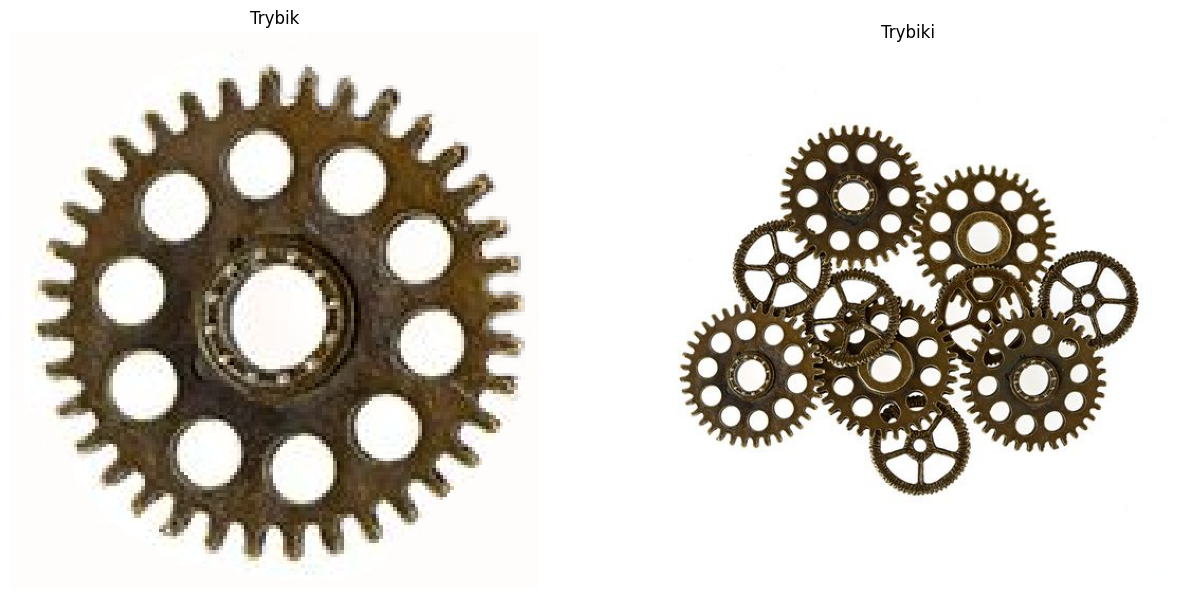

In [98]:
# Wyświetlenie wczytanych danych
fig, ax = plt.subplots(1, 2, figsize=(15, 10))
ax[0].imshow(trybik)
ax[0].axis('off')
ax[0].set_title('Trybik')
ax[1].imshow(trybik2)
ax[1].axis('off')
ax[1].set_title('Trybiki')
plt.show()

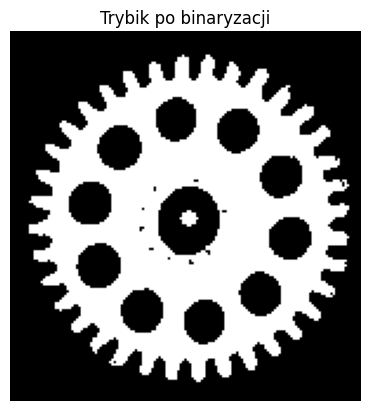

In [146]:
# Binaryzacja
trybik_gray = cv2.cvtColor(trybik, cv2.COLOR_RGB2GRAY)
_, trybik_binary = cv2.threshold(trybik_gray, 180, 255, cv2.THRESH_BINARY)
trybik_binary = cv2.bitwise_not(trybik_binary)

# Wyświetlenei zbinaryzowanego trybiku
plt.imshow(trybik_binary, cmap='gray')
plt.axis('off')
plt.title('Trybik po binaryzacji')
plt.show()

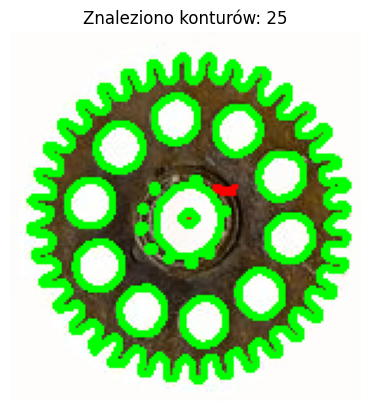

In [147]:
contours, _ = cv2.findContours(trybik_binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

trybik_with_contours = trybik.copy()

cv2.drawContours(trybik_with_contours, contours, -1, (0, 255, 0), 2)
plt.imshow(trybik_with_contours, cmap='gray')
plt.title(f'Znaleziono konturów: {len(contours)}')
plt.axis('off')
plt.show()

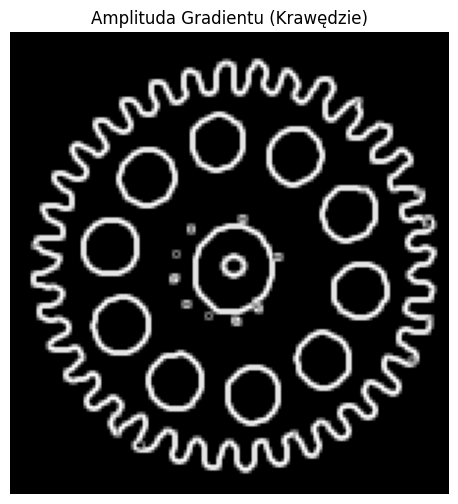

In [148]:
# Gradient - to "siła" jasności krawędzi

# Liczymy splot
sobel_x = cv2.Sobel(trybik_binary, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(trybik_binary, cv2.CV_64F, 0, 1, ksize=3)

# Liczymy kierunek gradientu
theta = np.atan2(sobel_y, sobel_x)
# Liczymy amplitudę
amp = cv2.magnitude(sobel_x, sobel_y)
# Normalizacja przez największą wartość
if np.max(amp) > 0:
    amp_norm = amp / np.max(amp)
else:
    amp_norm = amp

# Wyświetlanie wyliczonego gradientu
plt.figure(figsize=(10,6))
plt.imshow(amp  , cmap='gray')
plt.title("Amplituda Gradientu (Krawędzie)")
plt.axis('off')
plt.show()

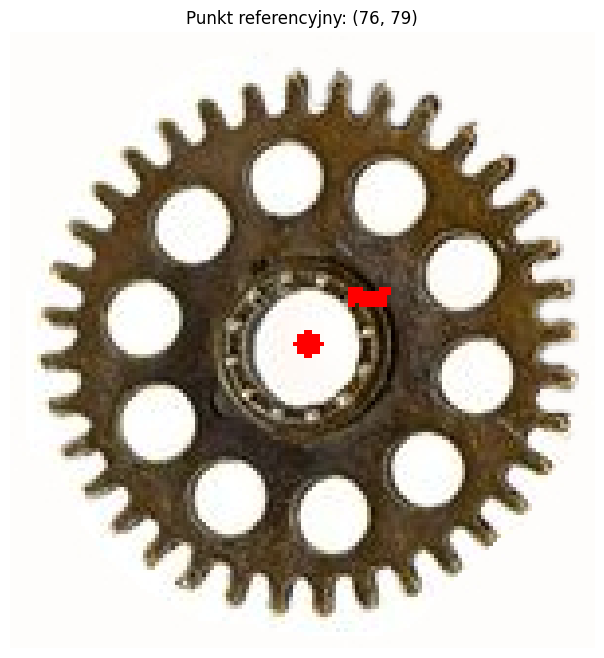

In [149]:
# Wyznaczanie punktu referencyjnego

# Wyznaczenie środka ciężkości
M = cv2.moments(trybik_binary)
if M['m00'] != 0:
    cX = int(M['m10'] / M['m00'])
    cY = int(M['m01'] / M['m00'])
else:
    cX, cY = 0, 0

# Dodajemy punkt i tekst do obrazu
cv2.circle(trybik, (cX, cY), 3, (255, 0, 0), -1) 
cv2.putText(trybik, "Ref", (cX+10, cY-10), cv2.FONT_HERSHEY_SIMPLEX, 0.2, (255, 0, 0), 0)

# Wyświetlamy
plt.figure(figsize=(8, 8))
plt.imshow(trybik)    
plt.title(f"Punkt referencyjny: ({cX}, {cY})")
plt.axis('off')         
plt.show()

In [150]:
Rtable = [[] for _ in range(360)]
for cn in contours:
    for point in cn:
        x = point[0, 0]
        y = point[0, 1]
        
        # Pobieramy kierunek gradientu dla punktu (x, y)
        phi_rad = theta[y, x]
        phi_deg = int((np.rad2deg(phi_rad)) % 360)
        
        # Liczymy wektor od (cX, cY) do (x, y)
        dx = cX - x
        dy = cY - y
        
        # Odległość
        r = np.sqrt(dx**2 + dy**2)
        
        # Kąt wektora względem OX
        alpha = np.arctan2(dy, dx)
        
        # Zapisujemy do tablicy
        Rtable[phi_deg].append((r, alpha))

# Sprawdzam czy coś się zapisało
print("Kąt: Ile")
for i in range(360):
    if len(Rtable[i]):
        print(i,":",len(Rtable[i]))

Kąt: Ile
0 : 128
18 : 60
26 : 31
45 : 79
63 : 31
71 : 61
90 : 110
108 : 61
116 : 34
135 : 68
153 : 34
161 : 63
180 : 120
198 : 53
206 : 31
225 : 91
243 : 34
251 : 49
270 : 110
288 : 54
296 : 40
315 : 67
333 : 39
341 : 57


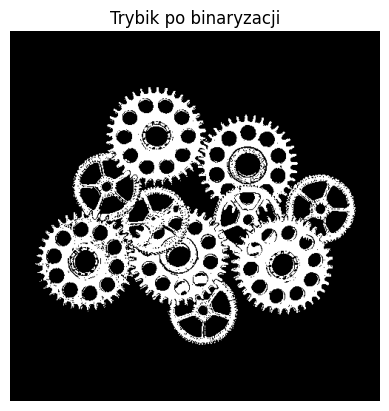

In [151]:
# Binaryzacja
trybik2_gray = cv2.cvtColor(trybik2, cv2.COLOR_RGB2GRAY)
_, trybik2_binary = cv2.threshold(trybik2_gray, 80, 255, cv2.THRESH_BINARY)
trybik2_binary = cv2.bitwise_not(trybik2_binary)

# Wyświetlenei zbinaryzowanego trybiku
plt.imshow(trybik2_binary, cmap='gray')
plt.axis('off')
plt.title('Trybik po binaryzacji')
plt.show()

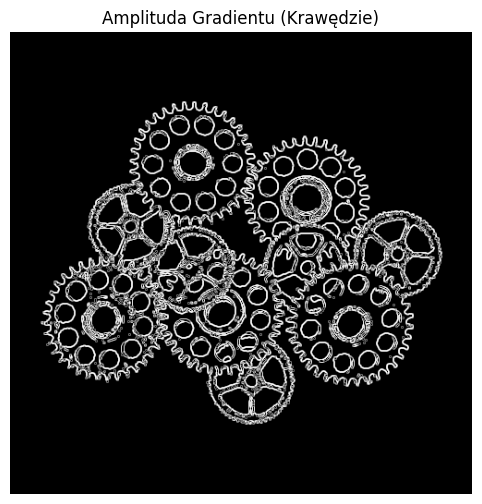

In [152]:
# Gradient - to "siła" jasności krawędzi

# Liczymy splot
sobel_x = cv2.Sobel(trybik2_binary, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(trybik2_binary, cv2.CV_64F, 0, 1, ksize=3)

# Liczymy kierunek gradientu
theta = np.atan2(sobel_y, sobel_x)
# Liczymy amplitudę
amp = cv2.magnitude(sobel_x, sobel_y)
# Normalizacja przez największą wartość
if np.max(amp) > 0:
    amp_norm = amp / np.max(amp)
else:
    amp_norm = amp

# Wyświetlanie wyliczonego gradientu
plt.figure(figsize=(10,6))
plt.imshow(amp, cmap='gray')
plt.title("Amplituda Gradientu (Krawędzie)")
plt.axis('off')
plt.show()

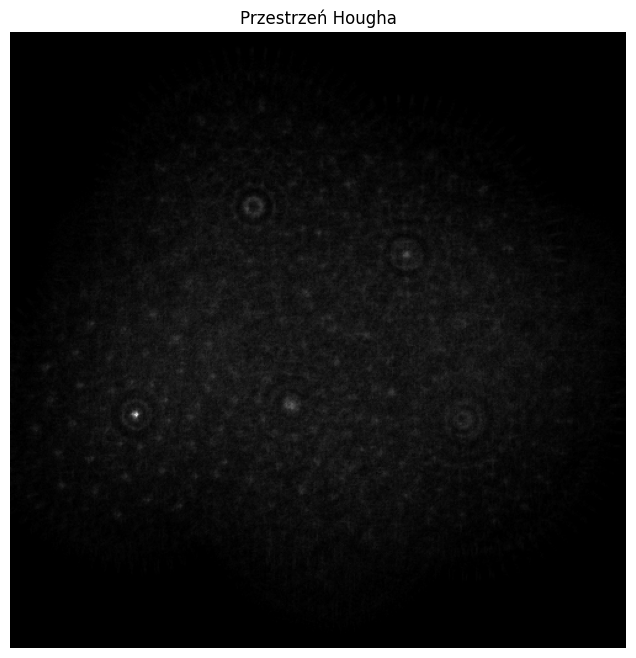

In [153]:
# Tworzymy pustą tablicę 
h, w = trybik2_gray.shape
accumulator = np.zeros((h, w))

# Iterujemy po każdym punkcie w trybiki2
for y in range(h):
    for x in range(w):
        # Jeżeli gradient jest większy pod 0.5
        if amp[y, x] > 0.5:
            # Pobieramy orientację w punkcie
            phi_deg = int(np.rad2deg(theta[y, x])) % 360
            # Pobieramy wektory dla punktu
            vectors = Rtable[phi_deg]
            for r, alpha in vectors:
                # Liczmy nowe x1, y1
                x1 = int(x + r * np.cos(alpha))
                y1 = int(y + r * np.sin(alpha))
                # Jeśli wyliczony środek mieści się w obrazie to dodajemy
                if 0 <= x1 < w and 0 <= y1 < h:
                    accumulator[y1, x1] += 1
                    
plt.figure(figsize=(10, 8))
plt.imshow(accumulator, cmap='gray')
plt.title("Przestrzeń Hougha")
plt.axis('off')
plt.show()

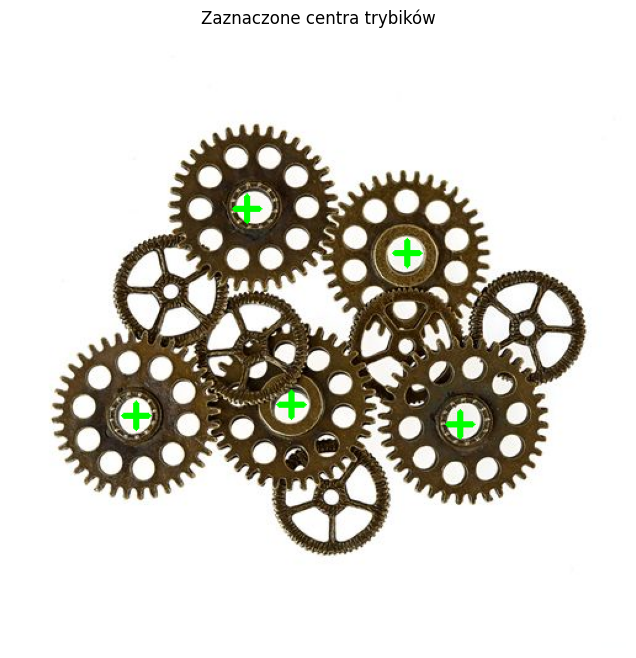

In [154]:
# Robimy kopię akumulatora, żeby nie zniszczyć oryginału
acc_temp = accumulator.copy()
found_centers = []

# Ile maksimów chcemy znaleźć
N = 5

# Promień wymazania żeby dokładnie wyznaczyć te maksima
clear_radius = 90

for i in range(N):
    # Znajduje aktualne maksimum
    _, max_val, _, max_loc = cv2.minMaxLoc(acc_temp)
    # Zapamiętuje współrzędne
    found_centers.append(max_loc)
    # Rysuje czarne kółko na kopii żeby go nie wziąć 2 raz
    cv2.circle(acc_temp, max_loc, clear_radius, 0, -1)

# Robię kopie do namalowania maksimum
result_img = trybik2.copy()

for i, pt in enumerate(found_centers):
    # Rysujemy krzyżyk w każdym znalezionym punkcie
    cv2.drawMarker(result_img, pt, (0, 255, 0), cv2.MARKER_CROSS, 20, 3)

# Wizualizacja
plt.figure(figsize=(10, 8))
plt.imshow(result_img)
plt.axis('off')
plt.title(f"Zaznaczone centra trybików")
plt.show()

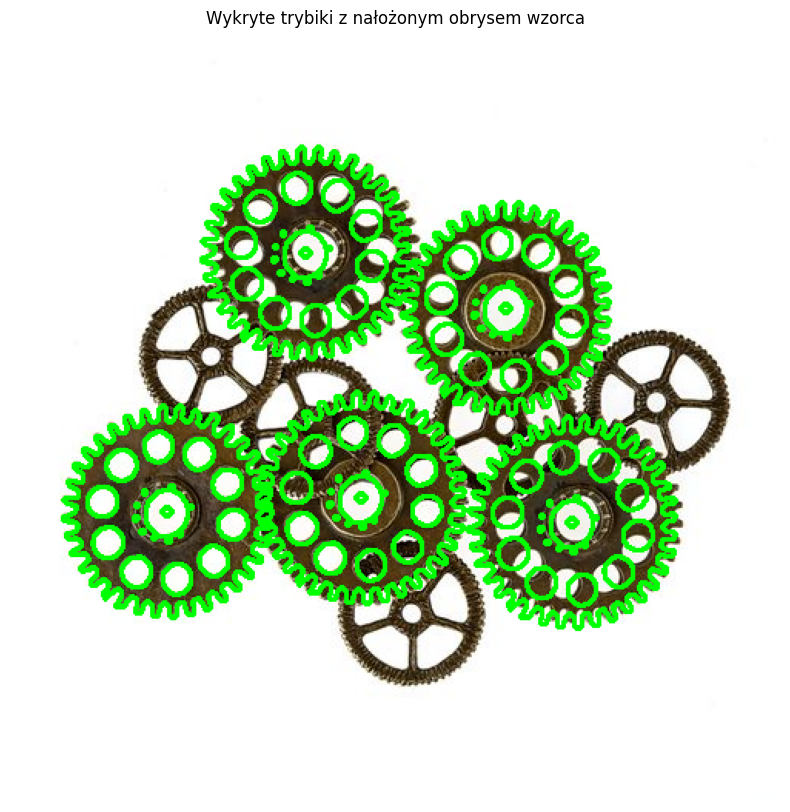

In [155]:
# Tworzę kopię do rysowania
result_with_outlines = trybik2.copy()

for pt in found_centers:
    # Biorę współrzędne środka
    fX, fY = pt  
    
    # Lista na przesunięte kontury dla tego konkretnego trybika
    shifted_contours = []
    
    for cn in contours:  
        shifted_cn = cn.astype(np.float32) 
        shifted_cn[:, 0, 0] = cn[:, 0, 0] - cX + fX
        shifted_cn[:, 0, 1] = cn[:, 0, 1] - cY + fY 
        shifted_contours.append(shifted_cn.astype(np.int32))
    
    # Rysownei konturów na obrazie
    cv2.drawContours(result_with_outlines, shifted_contours, -1, (0, 255, 0), 2)

# Wizuaolizacja efektu końcowego
plt.figure(figsize=(12, 10))
plt.imshow(result_with_outlines)
plt.title(f"Wykryte trybiki z nałożonym obrysem wzorca")
plt.axis('off')
plt.show()